In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.colors

In [2]:
# parameters
region_level = "nuts4"
year = 2017

**S1 - Description of the firm-level data**

In [ ]:
# map of employment / number of firms / ....

**S2 - Key variables and alternative measures**

In [3]:
def matrix_represantation(df, key_columns, sort_matrix, heatmap, fontsize, title_text, cmap, cbar_label, ax=None):
    """matrix or pivot table representation of our key variables"""
    table = df[key_columns]

    # undirected to directed -- to have a full matrix
    table2 = table.copy().rename(columns={"ind1": "ind2", "ind2": "ind1"})
    table2 = table2[key_columns]
    table = pd.concat([table, table2])

    # pivot transformation
    table = pd.pivot_table(table,
        values=key_columns[2],
        index=key_columns[0],
        columns=key_columns[1],
        aggfunc=np.max,
        margins=True,
        margins_name='total')

    # option to sort the matrix
    if sort_matrix == True:
        table = table\
            .sort_values(by=["total"], ascending=False, axis=0)\
            .sort_values(by=["total"], ascending=False, axis=1)
    else:
        table = table
    
    table = table.drop(["total"], axis=1).drop(["total"], axis=0)
    
    # option to keep the table or create heatmap
    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(
            table,
            cbar=True,
            cmap=cmap,
            ax=ax
        )
        ax.figure.axes[-1].set_ylabel(cbar_label, size=fontsize-5)
        ax.set_xlabel("Industry", size=fontsize)
        ax.set_ylabel("Industry", size=fontsize)
        ax.set_title(title_text, size=fontsize)
        ax.yaxis.set_tick_params(rotation=0, labelbottom=True)
        #ax.set_xticklabels("")
        #ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)

In [4]:
# KDE plots to illustrate distribution
def density_plot(df, key_column, colorway, xlabel_text, fontsize, ax=None):
    if ax is None:
        ax = plt.gca()

    sns.kdeplot(data=df,
        x=key_column,
        fill=True,
        color=colorway,
        linewidth=2.5,
        log_scale=False,
        ax=ax)
    
    ax.set_xlabel(xlabel_text, size=fontsize)
    ax.set_ylabel("Density", size=fontsize)
    ax.tick_params("x", labelsize=(fontsize-5))
    ax.tick_params("y", labelsize=(fontsize-5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

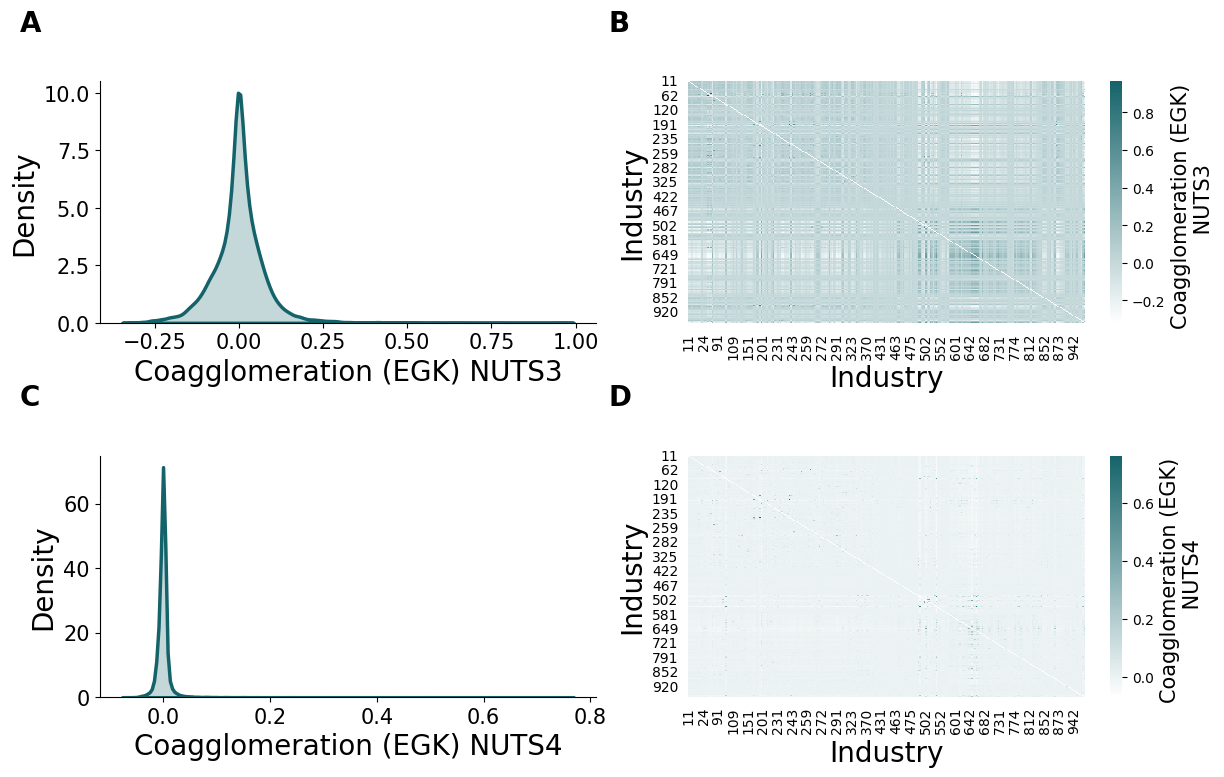

In [21]:
fig = plt.figure(figsize=(14, 8))
ax = [0]*4
gs = GridSpec(2,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
ax[2] = fig.add_subplot(gs[1,0])
ax[3] = fig.add_subplot(gs[1,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "egk_coagg"
region_levels = ["nuts3", "nuts4"]

# NUST3
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

# colormap
cvals  = [reg_df[key_var].min(), reg_df[key_var].max()]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Coagglomeration (EGK) NUTS3",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Coagglomeration (EGK) \n NUTS3",
    ax=ax[1]
)

# NUTS4
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[1]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

# colormap
cvals  = [reg_df[key_var].min(), reg_df[key_var].max()]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Coagglomeration (EGK) NUTS4",
    fontsize=textsize,
    ax=ax[2]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Coagglomeration (EGK) \n NUTS4",
    ax=ax[3]
)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/si_{key_var}_distributions.png", dpi=300, bbox_inches='tight', facecolor="white")

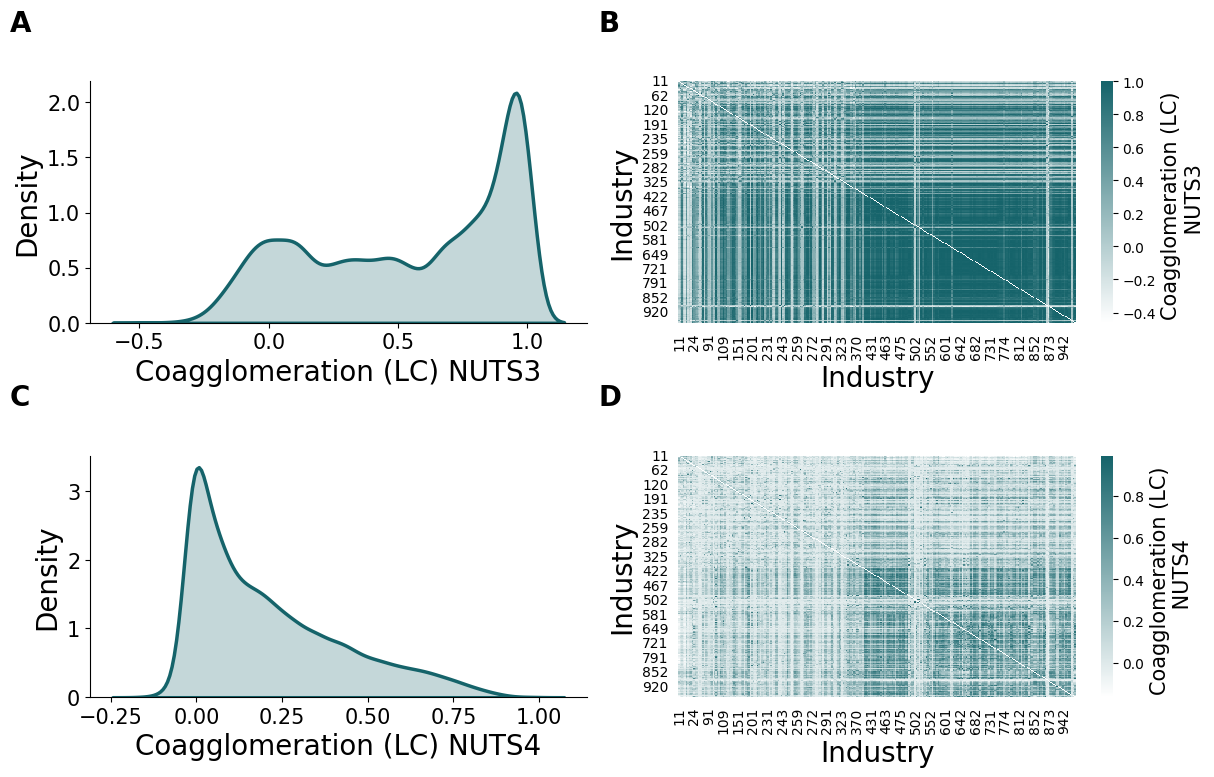

In [23]:
fig = plt.figure(figsize=(14, 8))
ax = [0]*4
gs = GridSpec(2,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
ax[2] = fig.add_subplot(gs[1,0])
ax[3] = fig.add_subplot(gs[1,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "coagg_porter_emp"
region_levels = ["nuts3", "nuts4"]

# colormap
cvals  = [reg_df[key_var].min(), reg_df[key_var].max()]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

# NUST3
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Coagglomeration (LC) NUTS3",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Coagglomeration (LC) \n NUTS3",
    ax=ax[1]
)


# NUTS4
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[1]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Coagglomeration (LC) NUTS4",
    fontsize=textsize,
    ax=ax[2]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Coagglomeration (LC) \n NUTS4",
    ax=ax[3]
)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/si_{key_var}_distributions.png", dpi=300, bbox_inches='tight', facecolor="white")

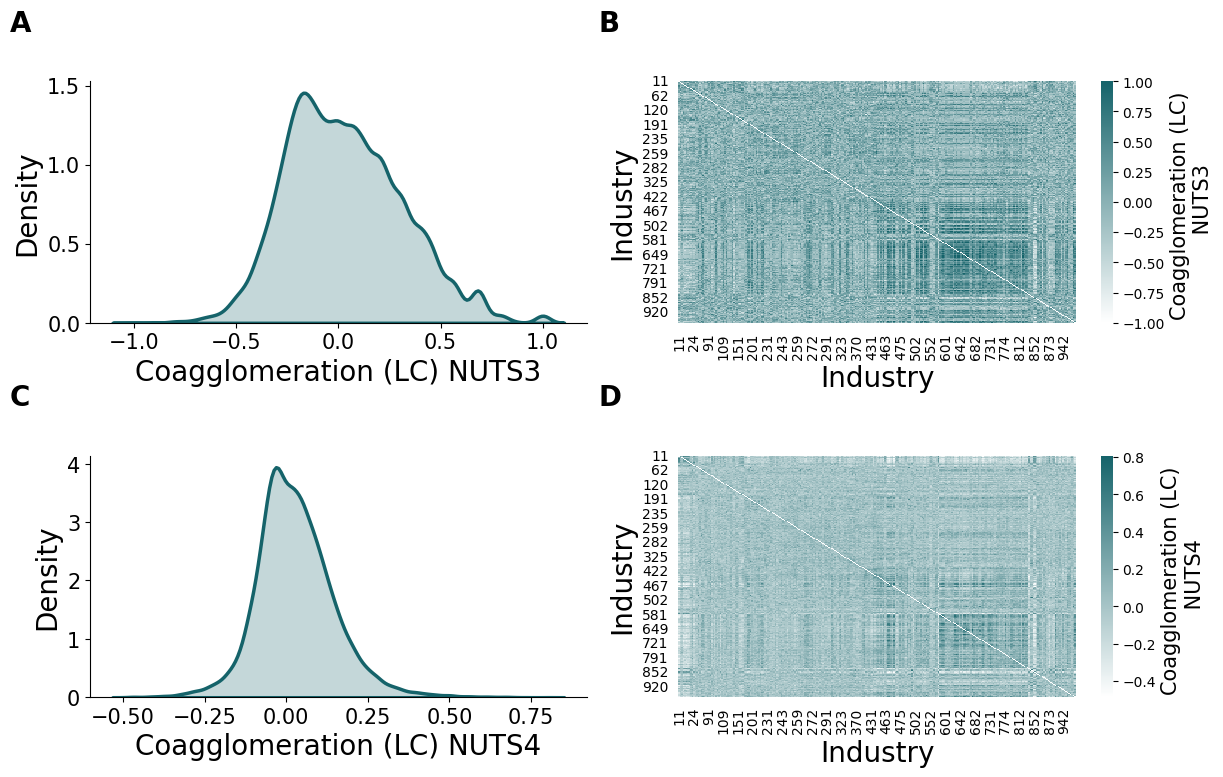

In [25]:
fig = plt.figure(figsize=(14, 8))
ax = [0]*4
gs = GridSpec(2,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
ax[2] = fig.add_subplot(gs[1,0])
ax[3] = fig.add_subplot(gs[1,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "coagg_porter_rca01"
region_levels = ["nuts3", "nuts4"]

# colormap
cvals  = [reg_df[key_var].min(), reg_df[key_var].max()]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

# NUST3
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Coagglomeration (LC) NUTS3",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Coagglomeration (LC) \n NUTS3",
    ax=ax[1]
)


# NUTS4
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[1]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Coagglomeration (LC) NUTS4",
    fontsize=textsize,
    ax=ax[2]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Coagglomeration (LC) \n NUTS4",
    ax=ax[3]
)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/si_{key_var}_distributions.png", dpi=300, bbox_inches='tight', facecolor="white")

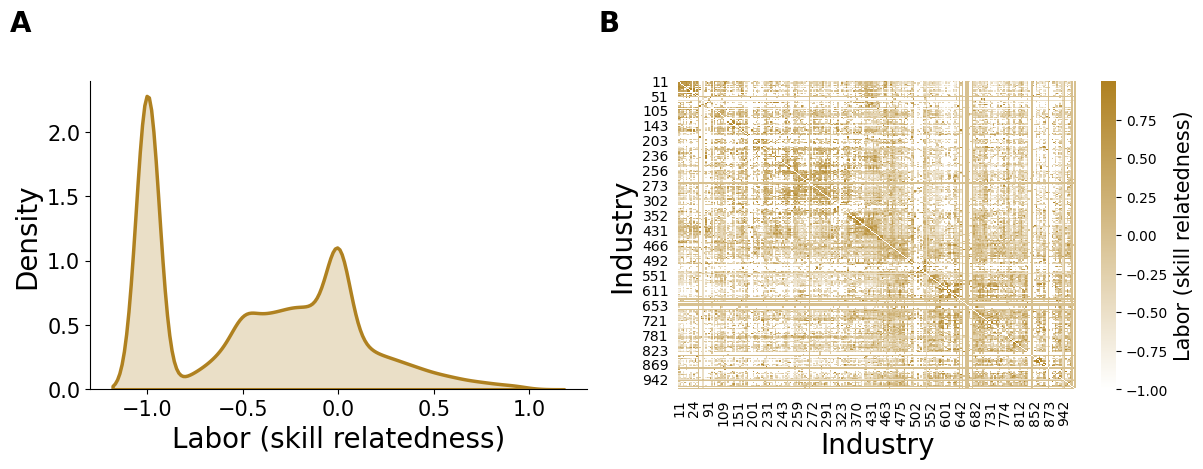

In [27]:
fig = plt.figure(figsize=(14, 4))
ax = [0]*2
gs = GridSpec(1,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "sr_norm"
region_levels = ["nuts3", "nuts4"]

# colormap
cvals  = [-1, 1]
colors = ["#FFFFFF","#AF8120"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

# NUST3
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Labor (skill relatedness)",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Labor (skill relatedness)",
    ax=ax[1]
)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/si_{key_var}_distributions.png", dpi=300, bbox_inches='tight', facecolor="white")

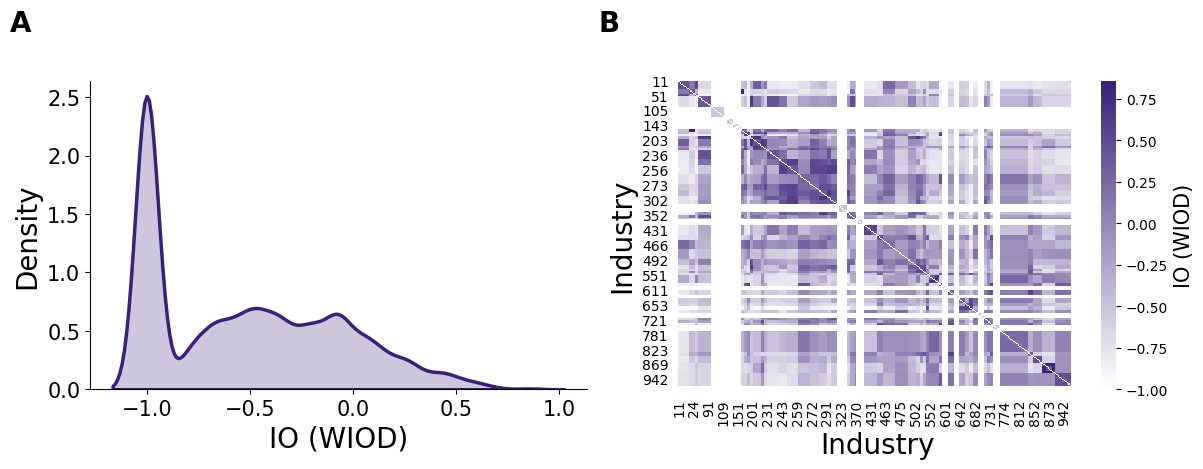

In [29]:
fig = plt.figure(figsize=(14, 4))
ax = [0]*2
gs = GridSpec(1,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "io_wiot_hun"
region_levels = ["nuts3", "nuts4"]

# colormap
cvals  = [-1, 1]
colors = ["#FFFFFF","#382178"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

# NUST3
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="IO (WIOD)",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="IO (WIOD)",
    ax=ax[1]
)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/si_{key_var}_distributions.png", dpi=300, bbox_inches='tight', facecolor="white")

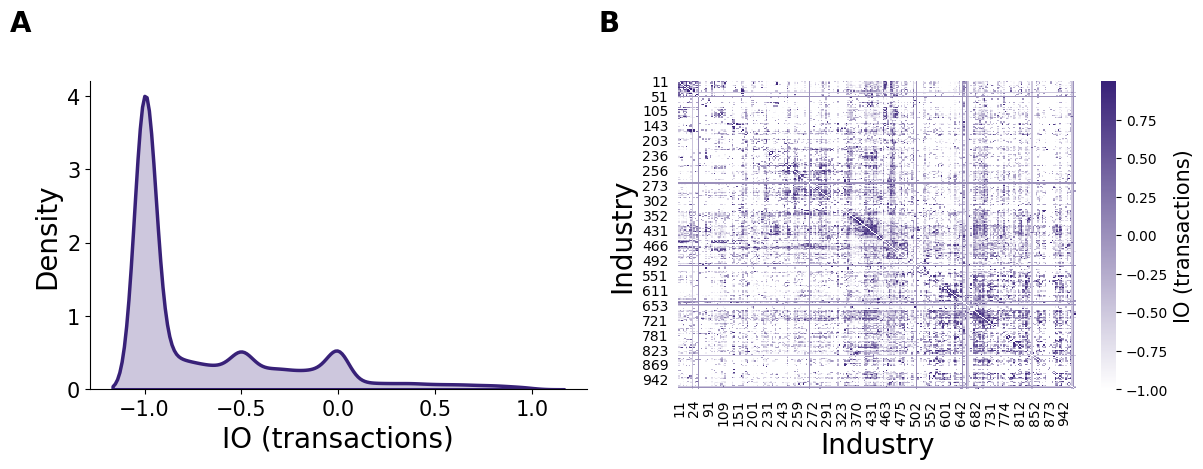

In [31]:
fig = plt.figure(figsize=(14, 4))
ax = [0]*2
gs = GridSpec(1,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "io_norm3"
region_levels = ["nuts3", "nuts4"]

# colormap
cvals  = [-1, 1]
colors = ["#FFFFFF","#382178"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

# NUST3
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="IO (transactions)",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="IO (transactions)",
    ax=ax[1]
)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/si_{key_var}_distributions.png", dpi=300, bbox_inches='tight', facecolor="white")

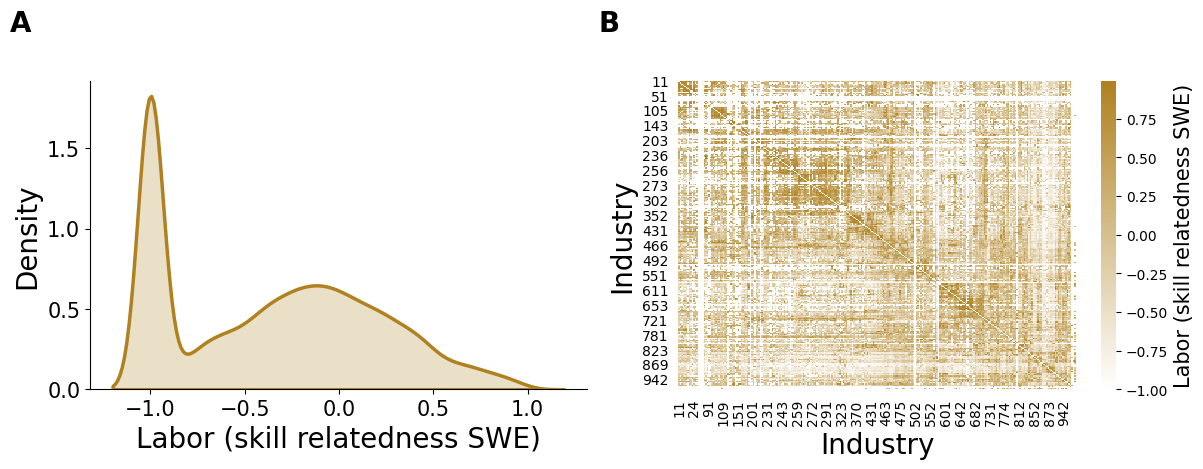

In [9]:
fig = plt.figure(figsize=(14, 4))
ax = [0]*2
gs = GridSpec(1,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "swe_sr_norm"
region_levels = ["nuts3", "nuts4"]

# colormap
cvals  = [-1, 1]
colors = ["#FFFFFF","#AF8120"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

# NUST3
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Labor (skill relatedness SWE)",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Labor (skill relatedness SWE)",
    ax=ax[1]
)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/si_{key_var}_distributions.png", dpi=300, bbox_inches='tight', facecolor="white")

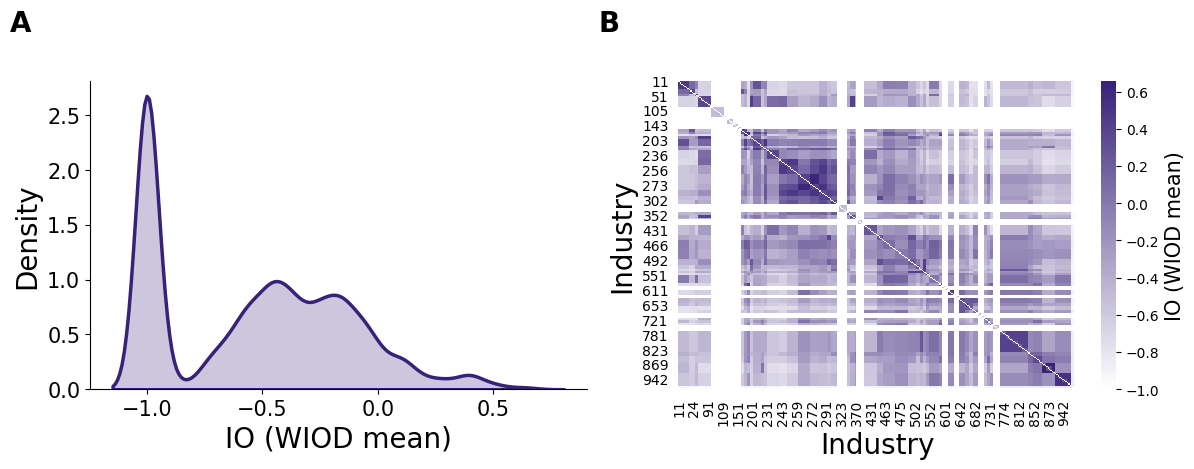

In [15]:
fig = plt.figure(figsize=(14, 4))
ax = [0]*2
gs = GridSpec(1,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "iv_wiot_mean"
region_levels = ["nuts3", "nuts4"]

# colormap
cvals  = [-1, 1]
colors = ["#FFFFFF","#382178"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

# NUST3
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

density_plot(
    reg_df,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="IO (WIOD mean)",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="IO (WIOD mean)",
    ax=ax[1]
)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/si_{key_var}_distributions.png", dpi=300, bbox_inches='tight', facecolor="white")

In [66]:
def correlation_matrix(data, key_columns, labels, textsize, cmap, heatmap=True, ax=None):
    """create heatmap from correlation matrix"""
    
    # only important columns
    data = data[key_columns]

    # correlation matrix
    corr_mat = data.corr()

    if heatmap==False:
        return corr_mat
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(corr_mat, cbar=False, annot=True, cmap=cmap, ax=ax)
        ax.set_xticklabels(labels, size=textsize)
        ax.set_yticklabels(labels, size=textsize)

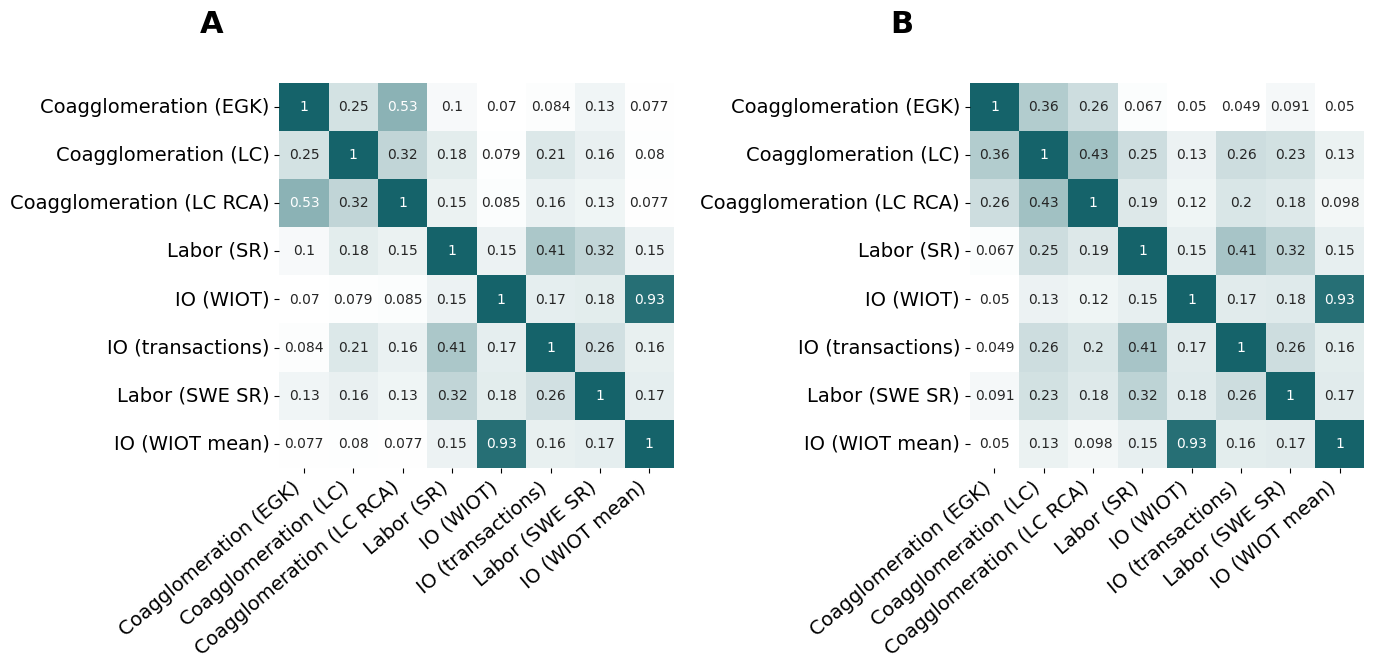

In [76]:
# correlation table
fig = plt.figure(figsize=(14, 5))
ax = [0]*2
gs = GridSpec(1,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
fig.subplots_adjust(wspace=0.75) 

textsize = 14
key_vars = ["egk_coagg", "coagg_porter_emp", "coagg_porter_rca01", "sr_norm", "io_norm3", "io_wiot_hun", "swe_sr_norm", "iv_wiot_mean"]
region_levels = ["nuts3", "nuts4"]

# colormap
cvals  = [0, 1]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

# NUST3
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[0]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]
reg_df = reg_df[key_vars]

# plot the matrix w/ style
corr_mat = reg_df.corr()

labels = ["Coagglomeration (EGK)", "Coagglomeration (LC)", "Coagglomeration (LC RCA)", "Labor (SR)", "IO (WIOT)", "IO (transactions)", "Labor (SWE SR)", "IO (WIOT mean)"]
correlation_matrix(
    reg_df,
    key_columns=["egk_coagg", "coagg_porter_emp", "coagg_porter_rca01", "sr_norm", "io_wiot_hun", "io_norm3", "swe_sr_norm", "iv_wiot_mean"],
    labels=labels,
    textsize=textsize,
    cmap=cmap,
    heatmap=True,
    ax=ax[0]
)
ax[0].set_xticklabels(labels, size=textsize, rotation=40, ha='right')

# NUST4
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[1]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]
reg_df = reg_df[key_vars]

# plot the matrix w/ style
corr_mat = reg_df.corr()

labels = ["Coagglomeration (EGK)", "Coagglomeration (LC)", "Coagglomeration (LC RCA)", "Labor (SR)", "IO (WIOT)", "IO (transactions)", "Labor (SWE SR)", "IO (WIOT mean)"]
correlation_matrix(
    reg_df,
    key_columns=["egk_coagg", "coagg_porter_emp", "coagg_porter_rca01", "sr_norm", "io_wiot_hun", "io_norm3", "swe_sr_norm", "iv_wiot_mean"],
    labels=labels,
    textsize=textsize,
    cmap=cmap,
    heatmap=True,
    ax=ax[1]
)
ax[1].set_xticklabels(labels, size=textsize, rotation=40, ha='right')

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize+8)

# plt.savefig(f"../figures/si_corr_matrix.png", dpi=300, bbox_inches='tight', facecolor="white")

In [ ]:
# baseline statistics table -- like Diodato et al. JUE

In [6]:
def matrix_represantation(df, key_columns, sort_matrix, heatmap, fontsize, title_text, cmap, ax=None):
    """matrix or pivot table representation of our key variables"""
    table = df[key_columns]

    # undirected to directed -- to have a full matrix
    table2 = table.copy().rename(columns={"ind1": "ind2", "ind2": "ind1"})
    table2 = table2[key_columns]
    table = pd.concat([table, table2])

    # pivot transformation
    table = pd.pivot_table(table,
        values=key_columns[2],
        index=key_columns[0],
        columns=key_columns[1],
        aggfunc=np.max,
        margins=True,
        margins_name='total')

    # option to sort the matrix
    if sort_matrix == True:
        table = table\
            .sort_values(by=["total"], ascending=False, axis=0)\
            .sort_values(by=["total"], ascending=False, axis=1)
    else:
        table = table
    
    table = table.drop(["total"], axis=1).drop(["total"], axis=0)
    
    # option to keep the table or create heatmap
    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap=cmap, ax=ax)
        ax.set_xlabel("Industry", size=fontsize)
        ax.set_ylabel("Industry", size=fontsize)
        ax.set_title(title_text, size=fontsize)
        ax.yaxis.set_tick_params(rotation=0, labelbottom=True)
        #ax.set_xticklabels("")
        #ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)

In [7]:
# KDE plots to illustrate distribution
def density_plot(df, key_column, colorway, xlabel_text, fontsize, ax=None):
    if ax is None:
        ax = plt.gca()

    sns.kdeplot(data=df,
        x=key_column,
        fill=True,
        color=colorway,
        linewidth=2.5,
        log_scale=False,
        ax=ax)
    
    ax.set_xlabel(xlabel_text, size=fontsize)
    ax.set_ylabel("Density", size=fontsize)
    ax.tick_params("x", labelsize=(fontsize-5))
    ax.tick_params("y", labelsize=(fontsize-5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

In [8]:
# import OC data for regression
reg_df = pd.read_csv(f"../data/oc13_2023_oct_3/04oc_data_{region_level}_{year}.csv", sep=";")

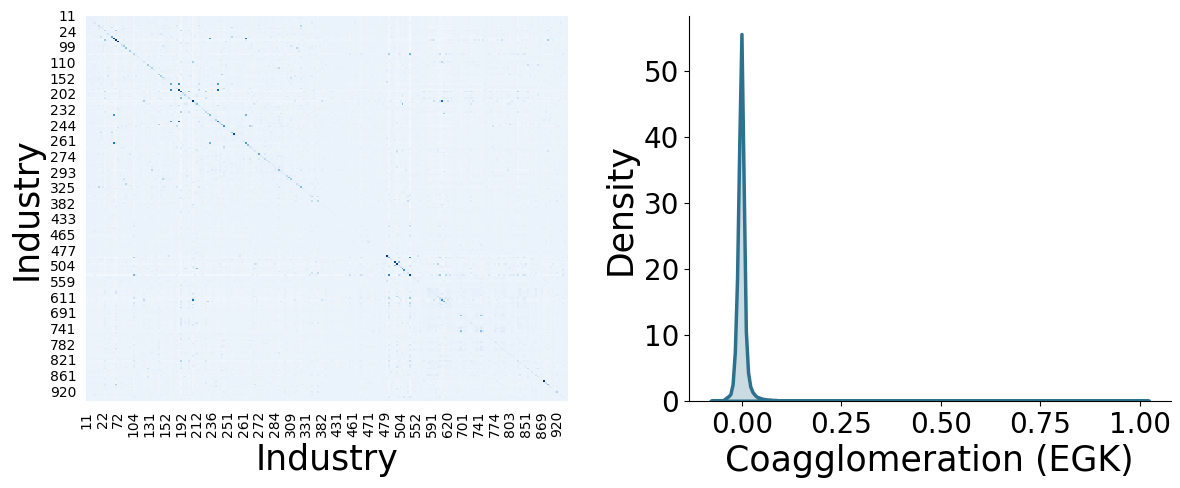

In [9]:
fig, ax = plt.subplots(1,2, figsize=(14, 5))
fig.subplots_adjust(wspace=0.25)
textsize = 25
key_var = "egk_coagg"
matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap="Blues",
    ax=ax[0]
)

density_plot(
    reg_df,
    key_column=key_var,
    colorway="#2C728EFF",
    xlabel_text="Coagglomeration (EGK)",
    fontsize=textsize
)

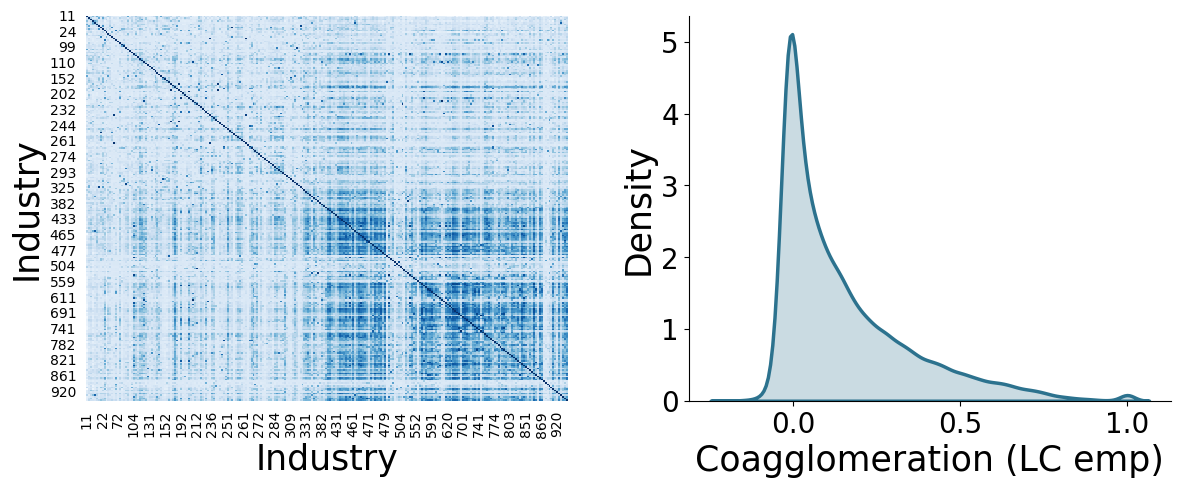

In [11]:
fig, ax = plt.subplots(1,2, figsize=(14, 5))
fig.subplots_adjust(wspace=0.25)
textsize = 25
key_var = "coagg_porter_emp"
matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap="Blues",
    ax=ax[0]
)

density_plot(
    reg_df,
    key_column=key_var,
    colorway="#2C728EFF",
    xlabel_text="Coagglomeration (LC emp)",
    fontsize=textsize
)

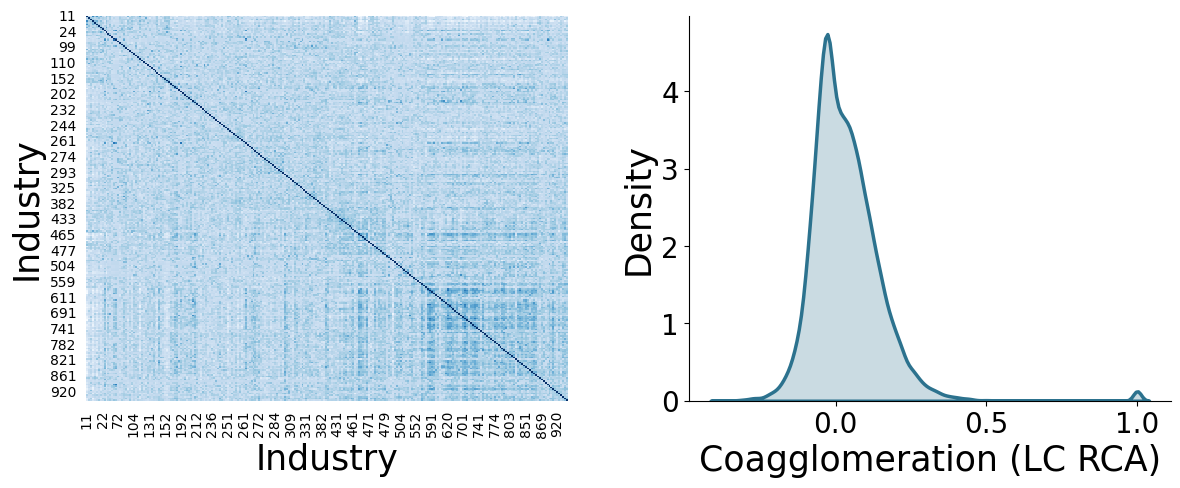

In [13]:
fig, ax = plt.subplots(1,2, figsize=(14, 5))
fig.subplots_adjust(wspace=0.25)
textsize = 25
key_var = "coagg_porter_rca01"
matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap="Blues",
    ax=ax[0]
)

density_plot(
    reg_df,
    key_column=key_var,
    colorway="#2C728EFF",
    xlabel_text="Coagglomeration (LC RCA)",
    fontsize=textsize
)

**S3 - independent variables -- labor flow**

In [ ]:
# import OC data for regression
reg_df = pd.read_csv(f"../data/oc13_2023_oct_3/04oc_data_{region_level}_{year}.csv", sep=";")

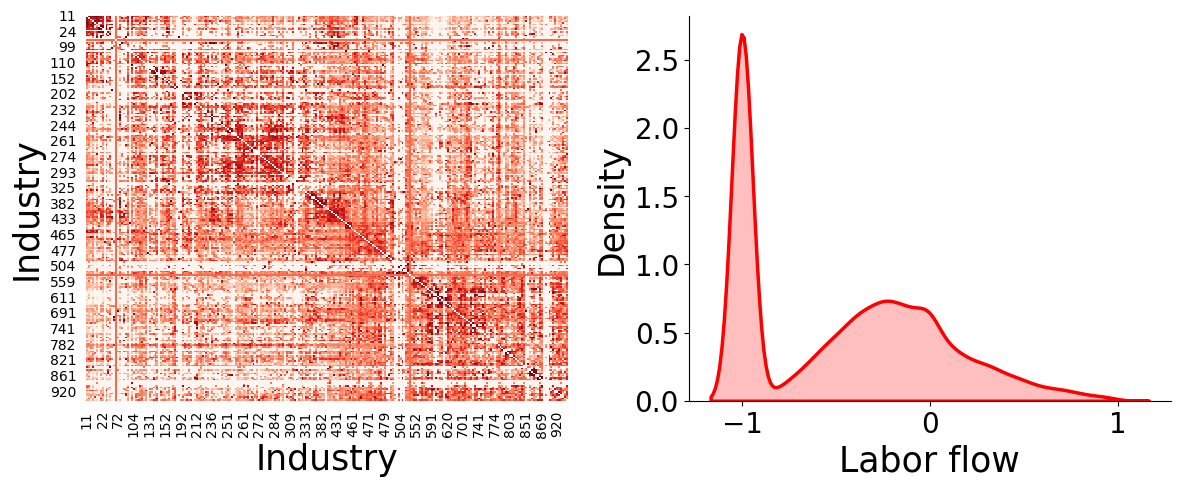

In [15]:
fig, ax = plt.subplots(1,2, figsize=(14, 5))
fig.subplots_adjust(wspace=0.25)
textsize = 25
key_var = "sr_norm"
matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap="Reds",
    ax=ax[0]
)

density_plot(
    reg_df,
    key_column=key_var,
    colorway="Red",
    xlabel_text="Labor flow",
    fontsize=textsize
)

**S4 - independent variables -- transaction data**

In [22]:
# import OC data for regression
reg_df = pd.read_csv(f"../data/oc13_2023_oct_3/04oc_data_{region_level}_{year}.csv", sep=";")

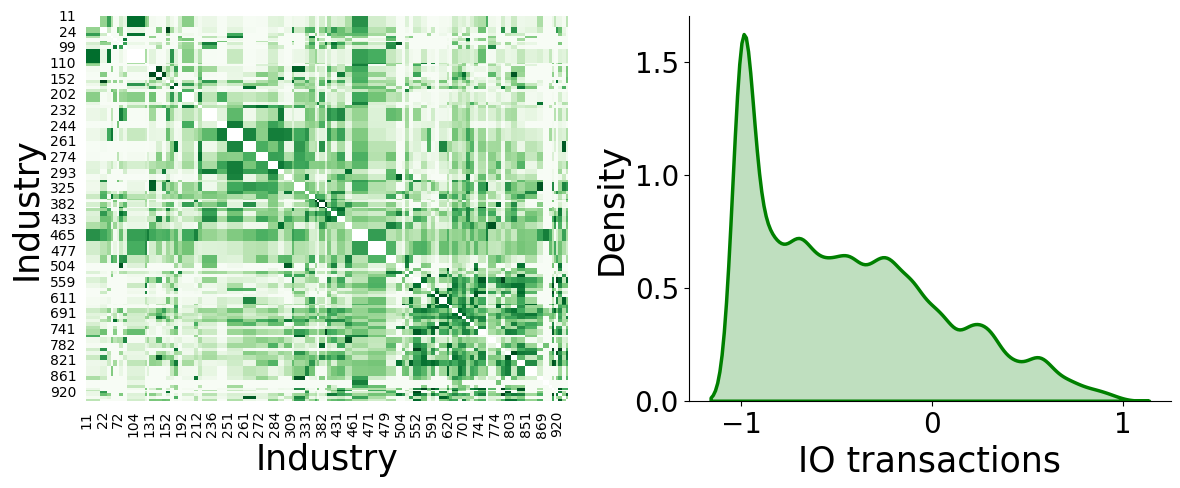

In [23]:
fig, ax = plt.subplots(1,2, figsize=(14, 5))
fig.subplots_adjust(wspace=0.25)
textsize = 25
key_var = "io_norm2"
matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap="Greens",
    ax=ax[0]
)

density_plot(
    reg_df,
    key_column=key_var,
    colorway="Green",
    xlabel_text="IO transactions",
    fontsize=textsize
)

**S5 - independent variables -- WIOT data**

In [ ]:
# import OC data for regression
reg_df = pd.read_csv(f"../data/oc13_2023_oct_3/04oc_data_{region_level}_{year}.csv", sep=";")

**S6 - instrumental variables**

In [ ]:
# import OC data for regression
reg_df = pd.read_csv(f"../data/oc13_2023_oct_3/04oc_data_{region_level}_{year}.csv", sep=";")

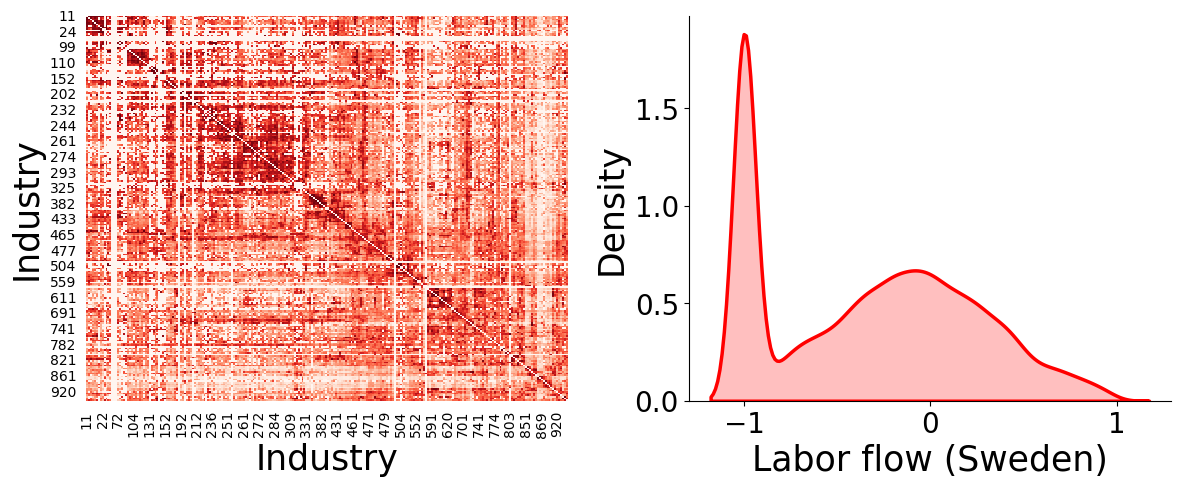

In [19]:
fig, ax = plt.subplots(1,2, figsize=(14, 5))
fig.subplots_adjust(wspace=0.25)
textsize = 25
key_var = "swe_sr_norm"
matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap="Reds",
    ax=ax[0]
)

density_plot(
    reg_df,
    key_column=key_var,
    colorway="Red",
    xlabel_text="Labor flow (Sweden)",
    fontsize=textsize
)

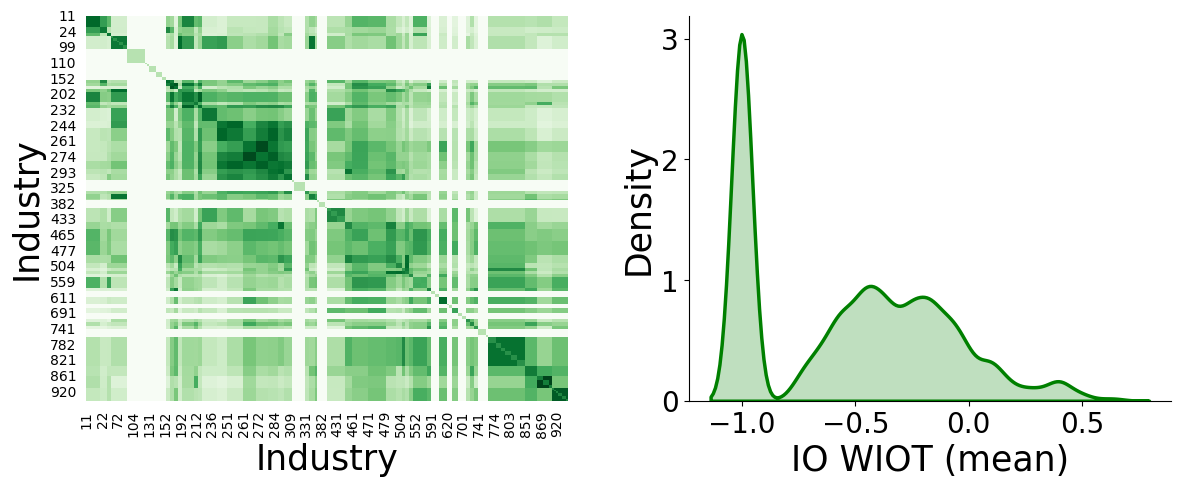

In [21]:
fig, ax = plt.subplots(1,2, figsize=(14, 5))
fig.subplots_adjust(wspace=0.25)
textsize = 25
key_var = "iv_wiot_mean"
matrix_represantation(
    reg_df,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap="Greens",
    ax=ax[0]
)

density_plot(
    reg_df,
    key_column=key_var,
    colorway="Green",
    xlabel_text="IO WIOT (mean)",
    fontsize=textsize
)

In [39]:
def scatter_for_two_variables(df, key_columns, colorway, labels, fontsize, ax=None):
    if ax is None:
        ax = plt.gca()
    ax.scatter(
        df[key_columns[0]],
        df[key_columns[1]],
        color=colorway,
        alpha=0.5
    )
    ax.set_xlabel(labels[0], size=fontsize)
    ax.set_ylabel(labels[1], size=fontsize)
    ax.tick_params("x", labelsize=(fontsize-5))
    ax.tick_params("y", labelsize=(fontsize-5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

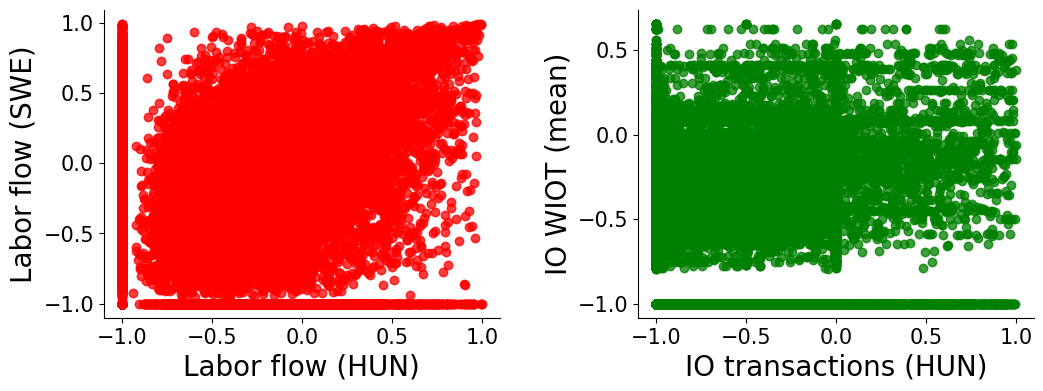

In [55]:
fig, ax = plt.subplots(1,2, figsize=(12, 4))
fig.subplots_adjust(wspace=0.35)
textsize = 20

scatter_for_two_variables(reg_df,
    key_columns=["sr_norm", "swe_sr_norm"],
    colorway="Red",
    labels=["Labor flow (HUN)", "Labor flow (SWE)"],
    fontsize=textsize,
    ax=ax[0]
)
scatter_for_two_variables(reg_df,
    key_columns=["io_norm3", "iv_wiot_mean"],
    colorway="Green",
    labels=["IO transactions (HUN)", "IO WIOT (mean)"],
    fontsize=textsize,
    ax=ax[1]
)